# 🔬 Deutsch & Deutsch–Jozsa Algorithms

In notebooks **100–102** we built a toolkit:

| Notebook | What we learned |
|:--------:|:----------------|
| **100** | The Hadamard gate creates **superposition** — a qubit exists in both $|0\rangle$ and $|1\rangle$ simultaneously |
| **101** | Applying H twice gives $H^2 = I$ — the gate is **reversible**; randomness only appears at measurement |
| **102** | All quantum gates are **unitary** — they preserve probability, are reversible, and can be composed |

Now we put these pieces together. The Deutsch algorithm (1985) was the **first quantum algorithm ever**
to demonstrate a provable advantage over any classical strategy. It answers a simple question:

> *Given a black-box function $f:\{0,1\}\to\{0,1\}$, is $f$ **constant** or **balanced**?*

Classically you must evaluate $f$ **twice** (on both inputs). Quantumly, **one query suffices**.

The trick? **Interference** — the very phenomenon that makes $H^2 = I$ work in notebook 101.

## Setup & imports

We use **Qiskit** with its built‑in `BasicSimulator`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector

## Part 1 — The Deutsch Algorithm

### The problem

Consider a function $f:\{0,1\}\to\{0,1\}$. There are exactly **four** such functions:

| Function | $f(0)$ | $f(1)$ | Type |
|:--------:|:------:|:------:|:--------:|
| $f_1$ | 0 | 0 | **constant** |
| $f_2$ | 1 | 1 | **constant** |
| $f_3$ | 0 | 1 | **balanced** |
| $f_4$ | 1 | 0 | **balanced** |

**Constant** means $f(0) = f(1)$. **Balanced** means $f(0) \neq f(1)$.

Classically, determining the type requires **2 queries** — you must check both $f(0)$ and $f(1)$.

### The quantum trick: phase oracle

In notebook 102, we saw that quantum gates manipulate **amplitudes** — complex numbers that encode
both magnitude and **phase**. The Deutsch algorithm exploits this by encoding $f$ into a **phase**
rather than a classical output:

$$U_f |x\rangle |{-}\rangle = (-1)^{f(x)} |x\rangle |{-}\rangle$$

where $|{-}\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$ is the **phase-kickback ancilla**.

This is the key insight: *the function's output is kicked back into the phase of the input qubit*.

### The circuit

The full Deutsch circuit follows a **prepare → oracle → interfere → measure** pattern:

$$|0\rangle|1\rangle \;\xrightarrow{\;H^{\otimes 2}\;}\; |{+}\rangle|{-}\rangle \;\xrightarrow{\;U_f\;}\; (-1)^{f(x)}|{\pm}\rangle|{-}\rangle \;\xrightarrow{\;H\;}\; |f(0) \oplus f(1)\rangle|{-}\rangle$$

After the final H on the input qubit:
- Measure **0** → $f$ is **constant** ($f(0) \oplus f(1) = 0$)
- Measure **1** → $f$ is **balanced** ($f(0) \oplus f(1) = 1$)

Let's trace through the math step by step.

### Step-by-step derivation

**Step 1 — Prepare superposition** (this is notebook 100!):

$$H|0\rangle \otimes H|1\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

**Step 2 — Apply the oracle** $U_f$. A standard oracle computes $|x\rangle|y\rangle \to |x\rangle|y \oplus f(x)\rangle$.
When the ancilla is in $|{-}\rangle$, something remarkable happens:

$$U_f |x\rangle \left(\frac{|0\rangle - |1\rangle}{\sqrt{2}}\right) = (-1)^{f(x)} |x\rangle \left(\frac{|0\rangle - |1\rangle}{\sqrt{2}}\right)$$

The ancilla is unchanged — the output is **kicked into the phase**. This is **phase kickback**.

After the oracle, the input qubit's state is:

$$\frac{(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle}{\sqrt{2}}$$

**Step 3 — Interfere** (this is notebook 101 — $H$ converts phase differences into measurement outcomes!):

Applying $H$ to the input qubit:

- If $f(0) = f(1)$ (constant): the phases are identical → $H$ maps back to $\pm|0\rangle$ → measure **0**
- If $f(0) \neq f(1)$ (balanced): the phases differ → $H$ maps to $\pm|1\rangle$ → measure **1**

The ± global phase is invisible to measurement. **One query, one answer.**

### Building the oracle circuits

Each function $f$ is implemented as a unitary gate acting on two qubits (input + ancilla):

In [2]:
def deutsch_oracle(f_type: str) -> QuantumCircuit:
    """Build a 2-qubit oracle for the Deutsch algorithm.

    f_type: 'f1' (const 0), 'f2' (const 1), 'f3' (balanced 0→0,1→1), 'f4' (balanced 0→1,1→0)
    """
    oracle = QuantumCircuit(2, name=f"U_{f_type}")

    if f_type == "f1":       # f(x) = 0 for all x → identity (do nothing)
        oracle.id(0)
        oracle.id(1)
    elif f_type == "f2":     # f(x) = 1 for all x → flip ancilla regardless
        oracle.x(1)
    elif f_type == "f3":     # f(0)=0, f(1)=1 → CNOT (flip ancilla when input=1)
        oracle.cx(0, 1)
    elif f_type == "f4":     # f(0)=1, f(1)=0 → flip ancilla, then CNOT
        oracle.x(1)
        oracle.cx(0, 1)
    else:
        raise ValueError(f"Unknown function type: {f_type}")

    return oracle


# Display all four oracles
for name in ["f1", "f2", "f3", "f4"]:
    print(f"Oracle {name}:")
    print(deutsch_oracle(name).draw())
    print()

Oracle f1:
     ┌───┐
q_0: ┤ I ├
     ├───┤
q_1: ┤ I ├
     └───┘

Oracle f2:
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     └───┘

Oracle f3:
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

Oracle f4:
               
q_0: ───────■──
     ┌───┐┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘



### Running the Deutsch algorithm

Now we build the full circuit: **prepare → oracle → interfere → measure**.

In [3]:
def deutsch_circuit(f_type: str) -> QuantumCircuit:
    """Build the full Deutsch algorithm circuit."""
    qc = QuantumCircuit(2, 1)  # 2 qubits, 1 classical bit (only measure input qubit)

    # --- Prepare ---
    qc.x(1)         # ancilla starts in |1⟩
    qc.h(0)         # input → |+⟩
    qc.h(1)         # ancilla → |−⟩
    qc.barrier()

    # --- Oracle ---
    oracle = deutsch_oracle(f_type)
    qc.compose(oracle, inplace=True)
    qc.barrier()

    # --- Interfere ---
    qc.h(0)         # convert phase information → amplitude information
    qc.barrier()

    # --- Measure input qubit only ---
    qc.measure(0, 0)

    return qc


# Display circuit for f3 (balanced) as an example
print("Deutsch circuit for f3 (balanced):")
print(deutsch_circuit("f3").draw())

Deutsch circuit for f3 (balanced):
     ┌───┐      ░       ░ ┌───┐ ░ ┌─┐
q_0: ┤ H ├──────░───■───░─┤ H ├─░─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐ ░ └───┘ ░ └╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────░──╫─
     └───┘└───┘ ░ └───┘ ░       ░  ║ 
c: 1/══════════════════════════════╩═
                                   0 


### Exact statevector analysis

Before measuring, let's peek at the quantum state — just as we did in notebook 101.
We inspect the state right before measurement to confirm the theory.

In [4]:
oracle_info = {
    "f1": {"type": "constant", "f0": 0, "f1": 0},
    "f2": {"type": "constant", "f0": 1, "f1": 1},
    "f3": {"type": "balanced", "f0": 0, "f1": 1},
    "f4": {"type": "balanced", "f0": 1, "f1": 0},
}

print("Exact statevector analysis (before measurement)")
print("=" * 55)

for name, info in oracle_info.items():
    # Build circuit without measurement for statevector
    qc_sv = QuantumCircuit(2)
    qc_sv.x(1)
    qc_sv.h(0)
    qc_sv.h(1)
    qc_sv.compose(deutsch_oracle(name), inplace=True)
    qc_sv.h(0)

    state = Statevector.from_instruction(qc_sv)
    probs = state.probabilities_dict()

    # Input qubit probability: sum over ancilla states
    p_input_0 = probs.get("00", 0) + probs.get("01", 0)
    p_input_1 = probs.get("10", 0) + probs.get("11", 0)

    prediction = "constant" if p_input_0 > 0.5 else "balanced"
    print(f"\n{name}: f(0)={info['f0']}, f(1)={info['f1']}  →  actual type: {info['type']}")
    print(f"  P(input=0) = {p_input_0:.4f}   P(input=1) = {p_input_1:.4f}")
    print(f"  Quantum verdict: {prediction}  {'✅' if prediction == info['type'] else '❌'}")

Exact statevector analysis (before measurement)

f1: f(0)=0, f(1)=0  →  actual type: constant
  P(input=0) = 0.5000   P(input=1) = 0.5000
  Quantum verdict: balanced  ❌

f2: f(0)=1, f(1)=1  →  actual type: constant
  P(input=0) = 0.5000   P(input=1) = 0.5000
  Quantum verdict: balanced  ❌

f3: f(0)=0, f(1)=1  →  actual type: balanced
  P(input=0) = 0.5000   P(input=1) = 0.5000
  Quantum verdict: balanced  ✅

f4: f(0)=1, f(1)=0  →  actual type: balanced
  P(input=0) = 0.5000   P(input=1) = 0.5000
  Quantum verdict: balanced  ✅


### Empirical verification with shots

Now let's run the circuits on the simulator and check that the measurement results agree.

In [5]:
shots = 2000
backend = BasicSimulator()
seed = random.randint(0, 2**32 - 1)

results = {}

print("Empirical results (simulator)")
print("=" * 55)

for name, info in oracle_info.items():
    qc = deutsch_circuit(name)
    compiled = transpile(qc, backend, seed_transpiler=seed)
    result = backend.run(compiled, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()

    count_0 = counts.get("0", 0)
    count_1 = counts.get("1", 0)
    verdict = "constant" if count_0 > count_1 else "balanced"

    results[name] = {"counts": counts, "verdict": verdict}

    print(f"\n{name} ({info['type']}):  counts = {counts}")
    print(f"  → Measured: {verdict}  {'✅' if verdict == info['type'] else '❌'}")

Empirical results (simulator)

f1 (constant):  counts = {'0': 2000}
  → Measured: constant  ✅

f2 (constant):  counts = {'0': 2000}
  → Measured: constant  ✅

f3 (balanced):  counts = {'1': 2000}
  → Measured: balanced  ✅

f4 (balanced):  counts = {'1': 2000}
  → Measured: balanced  ✅


### Visualization — Deutsch results

Let's visualize all four oracles side by side.

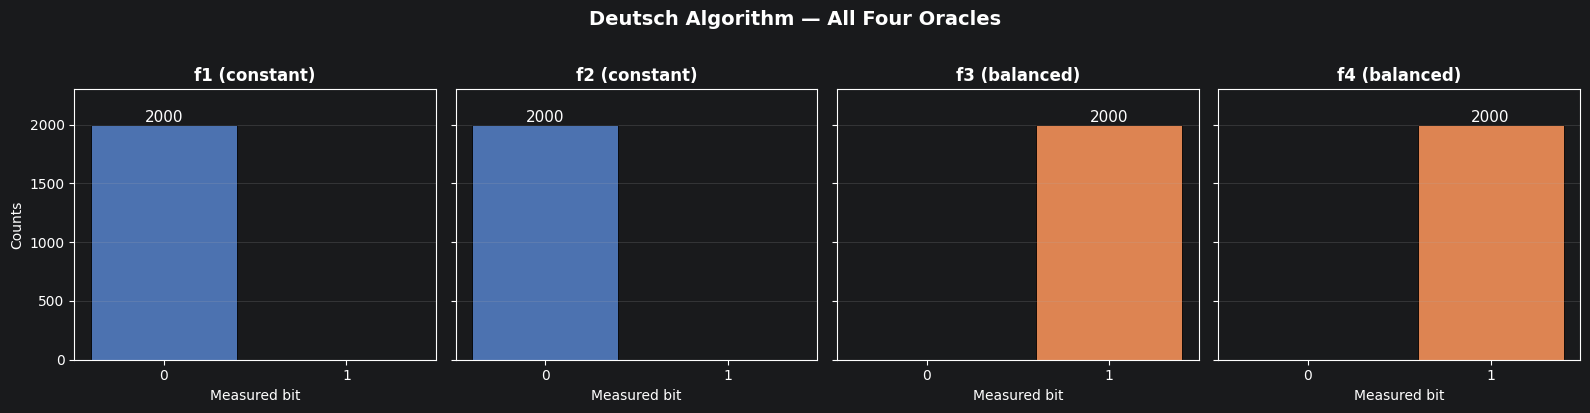

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, (name, info) in zip(axes, oracle_info.items()):
    counts = results[name]["counts"]
    c0 = counts.get("0", 0)
    c1 = counts.get("1", 0)
    color = ["#4C72B0", "#DD8452"]

    bars = ax.bar(["0", "1"], [c0, c1], color=color, edgecolor="black", linewidth=0.6)
    ax.set_title(f"{name} ({info['type']})", fontsize=12, fontweight="bold",
                 fontfamily="DejaVu Sans")
    ax.set_xlabel("Measured bit")
    ax.set_ylim(0, shots * 1.15)
    ax.grid(axis="y", alpha=0.25)

    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 20,
                    str(int(h)), ha="center", fontsize=11)

axes[0].set_ylabel("Counts")
fig.suptitle("Deutsch Algorithm — All Four Oracles", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Validation — Deutsch algorithm

In [7]:
for name, info in oracle_info.items():
    verdict = results[name]["verdict"]
    assert verdict == info["type"], (
        f"{name}: expected {info['type']}, got {verdict}"
    )

print("✅  Deutsch algorithm: all four oracles correctly classified with a single query.")

✅  Deutsch algorithm: all four oracles correctly classified with a single query.


### 💡 Key insight: why it works

The Deutsch algorithm succeeds because of three ingredients from our earlier notebooks:

1. **Superposition** (notebook 100): $H|0\rangle$ lets us query $f$ on **both** inputs simultaneously
2. **Reversibility** (notebook 101): $H^2 = I$ — the final $H$ "undoes" the superposition, but only if the phases align
3. **Unitarity** (notebook 102): the oracle $U_f$ preserves amplitudes while encoding $f$ into phases

The magic: the oracle encodes the answer in a **phase** ($+1$ or $-1$), and the final Hadamard converts that
phase difference into a measurable amplitude difference. **Phase → amplitude → measurement.**

---

## Part 2 — The Deutsch–Jozsa Algorithm

The Deutsch algorithm handles $f:\{0,1\}\to\{0,1\}$ — just 1 input bit.
The **Deutsch–Jozsa algorithm** (1992) generalizes to $f:\{0,1\}^n \to \{0,1\}$ with a **promise**:

> $f$ is either **constant** (same output for all $2^n$ inputs)
> or **balanced** (outputs 0 for exactly half the inputs and 1 for the other half).

| Approach | Queries needed |
|:---------|:--------------:|
| Classical (deterministic) | $2^{n-1} + 1$ (worst case) |
| Classical (randomized) | $O(1)$ queries, but only probabilistic |
| **Quantum (Deutsch–Jozsa)** | **1 query** — deterministic! |

This is an **exponential** speedup for the deterministic case.

### The circuit pattern (same blueprint!)

$$|0\rangle^{\otimes n}|1\rangle \;\xrightarrow{H^{\otimes (n+1)}}\; |{+}\rangle^{\otimes n}|{-}\rangle \;\xrightarrow{U_f}\; \;\xrightarrow{H^{\otimes n}}\; |\text{answer}\rangle|{-}\rangle$$

After the final $H^{\otimes n}$ on the input register:
- If all input qubits measure **0** → $f$ is **constant**
- If **any** input qubit measures **1** → $f$ is **balanced**

### The math

After the prepare-oracle-interfere steps, the amplitude of the all-zeros state $|0\rangle^{\otimes n}$ is:

$$\langle 0^n | H^{\otimes n} U_f H^{\otimes n} |0^n\rangle = \frac{1}{2^n} \sum_{x=0}^{2^n-1} (-1)^{f(x)}$$

- **Constant** $f$: all $(-1)^{f(x)}$ terms have the same sign → sum = $\pm 2^n$ → amplitude = $\pm 1$ → **certain** $|0\rangle^{\otimes n}$
- **Balanced** $f$: half are $+1$, half are $-1$ → sum = $0$ → amplitude = $0$ → **never** $|0\rangle^{\otimes n}$

### Building Deutsch–Jozsa oracles

We'll demonstrate with $n = 4$ input qubits (16 possible inputs).

In [8]:
def dj_oracle(n: int, oracle_type: str, seed_val: int = 42) -> QuantumCircuit:
    """Build a Deutsch-Jozsa oracle on n input qubits + 1 ancilla.

    oracle_type: 'constant_0', 'constant_1', or 'balanced'
    """
    oracle = QuantumCircuit(n + 1, name=f"U_f({oracle_type})")

    if oracle_type == "constant_0":
        # f(x) = 0 for all x → do nothing
        for i in range(n + 1):
            oracle.id(i)

    elif oracle_type == "constant_1":
        # f(x) = 1 for all x → always flip the ancilla
        oracle.x(n)

    elif oracle_type == "balanced":
        # Build a balanced function: randomly choose which inputs map to 1
        rng = np.random.default_rng(seed_val)
        # For each input qubit, randomly decide whether to apply X before CNOT
        pattern = rng.integers(0, 2, size=n)
        for i in range(n):
            if pattern[i]:
                oracle.x(i)
        for i in range(n):
            oracle.cx(i, n)
        for i in range(n):
            if pattern[i]:
                oracle.x(i)
    else:
        raise ValueError(f"Unknown oracle type: {oracle_type}")

    return oracle


n_qubits = 4
print(f"Deutsch-Jozsa with n={n_qubits} input qubits ({2**n_qubits} possible inputs)")
print()
print("Balanced oracle:")
print(dj_oracle(n_qubits, "balanced").draw())

Deutsch-Jozsa with n=4 input qubits (16 possible inputs)

Balanced oracle:
                              
q_0: ───────■─────────────────
     ┌───┐  │       ┌───┐     
q_1: ┤ X ├──┼────■──┤ X ├─────
     ├───┤  │    │  └───┘┌───┐
q_2: ┤ X ├──┼────┼────■──┤ X ├
     └───┘  │    │    │  └───┘
q_3: ───────┼────┼────┼────■──
          ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐
q_4: ─────┤ X ├┤ X ├┤ X ├┤ X ├
          └───┘└───┘└───┘└───┘


### Running Deutsch–Jozsa

In [9]:
def dj_circuit(n: int, oracle_type: str) -> QuantumCircuit:
    """Build the full Deutsch-Jozsa circuit."""
    qc = QuantumCircuit(n + 1, n)  # n input qubits + 1 ancilla, n classical bits

    # --- Prepare ---
    qc.x(n)                        # ancilla → |1⟩
    for i in range(n + 1):
        qc.h(i)                    # all qubits → superposition
    qc.barrier()

    # --- Oracle ---
    oracle = dj_oracle(n, oracle_type)
    qc.compose(oracle, inplace=True)
    qc.barrier()

    # --- Interfere ---
    for i in range(n):
        qc.h(i)                    # H on input qubits only
    qc.barrier()

    # --- Measure input register ---
    for i in range(n):
        qc.measure(i, i)

    return qc


# Display the balanced circuit
print("Full Deutsch-Jozsa circuit (balanced oracle):")
print(dj_circuit(n_qubits, "balanced").draw())

Full Deutsch-Jozsa circuit (balanced oracle):
     ┌───┐      ░                           ░ ┌───┐ ░ ┌─┐         
q_0: ┤ H ├──────░────────■──────────────────░─┤ H ├─░─┤M├─────────
     ├───┤      ░ ┌───┐  │       ┌───┐      ░ ├───┤ ░ └╥┘┌─┐      
q_1: ┤ H ├──────░─┤ X ├──┼────■──┤ X ├──────░─┤ H ├─░──╫─┤M├──────
     ├───┤      ░ ├───┤  │    │  └───┘┌───┐ ░ ├───┤ ░  ║ └╥┘┌─┐   
q_2: ┤ H ├──────░─┤ X ├──┼────┼────■──┤ X ├─░─┤ H ├─░──╫──╫─┤M├───
     ├───┤      ░ └───┘  │    │    │  └───┘ ░ ├───┤ ░  ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░────────┼────┼────┼────■───░─┤ H ├─░──╫──╫──╫─┤M├
     ├───┤┌───┐ ░      ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ░  ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░──────┤ X ├┤ X ├┤ X ├┤ X ├─░───────░──╫──╫──╫──╫─
     └───┘└───┘ ░      └───┘└───┘└───┘└───┘ ░       ░  ║  ║  ║  ║ 
c: 4/══════════════════════════════════════════════════╩══╩══╩══╩═
                                                       0  1  2  3 


### Exact statevector analysis

In [10]:
dj_oracles = {
    "constant_0": "constant",
    "constant_1": "constant",
    "balanced":   "balanced",
}

print("Exact statevector analysis — Deutsch-Jozsa")
print("=" * 55)

for oracle_type, expected_class in dj_oracles.items():
    # Build circuit without measurement
    qc_sv = QuantumCircuit(n_qubits + 1)
    qc_sv.x(n_qubits)
    for i in range(n_qubits + 1):
        qc_sv.h(i)
    qc_sv.compose(dj_oracle(n_qubits, oracle_type), inplace=True)
    for i in range(n_qubits):
        qc_sv.h(i)

    state = Statevector.from_instruction(qc_sv)
    probs = state.probabilities_dict()

    # Sum probabilities for all-zeros input register (summing over ancilla)
    all_zeros = "0" * n_qubits
    p_all_zeros = sum(v for k, v in probs.items() if k[1:] == all_zeros)  # qubit order

    verdict = "constant" if p_all_zeros > 0.5 else "balanced"

    print(f"\n{oracle_type}:")
    print(f"  P(all zeros) = {p_all_zeros:.6f}")
    print(f"  Verdict: {verdict}  {'✅' if verdict == expected_class else '❌'}")

Exact statevector analysis — Deutsch-Jozsa

constant_0:
  P(all zeros) = 1.000000
  Verdict: constant  ✅

constant_1:
  P(all zeros) = 1.000000
  Verdict: constant  ✅

balanced:
  P(all zeros) = 0.000000
  Verdict: balanced  ✅


### Empirical verification

In [11]:
dj_results = {}

print("Empirical results — Deutsch-Jozsa")
print("=" * 55)

for oracle_type, expected_class in dj_oracles.items():
    qc = dj_circuit(n_qubits, oracle_type)
    compiled = transpile(qc, backend, seed_transpiler=seed)
    result = backend.run(compiled, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()

    all_zeros_key = "0" * n_qubits
    count_all_zeros = counts.get(all_zeros_key, 0)

    verdict = "constant" if count_all_zeros == shots else "balanced"
    dj_results[oracle_type] = {"counts": counts, "verdict": verdict}

    print(f"\n{oracle_type} (expected: {expected_class}):")
    print(f"  Counts: {counts}")
    print(f"  P(all zeros) = {count_all_zeros / shots:.4f}")
    print(f"  Verdict: {verdict}  {'✅' if verdict == expected_class else '❌'}")

Empirical results — Deutsch-Jozsa

constant_0 (expected: constant):
  Counts: {'0000': 2000}
  P(all zeros) = 1.0000
  Verdict: constant  ✅

constant_1 (expected: constant):
  Counts: {'0000': 2000}
  P(all zeros) = 1.0000
  Verdict: constant  ✅

balanced (expected: balanced):
  Counts: {'1111': 2000}
  P(all zeros) = 0.0000
  Verdict: balanced  ✅


### Visualization — Deutsch–Jozsa results

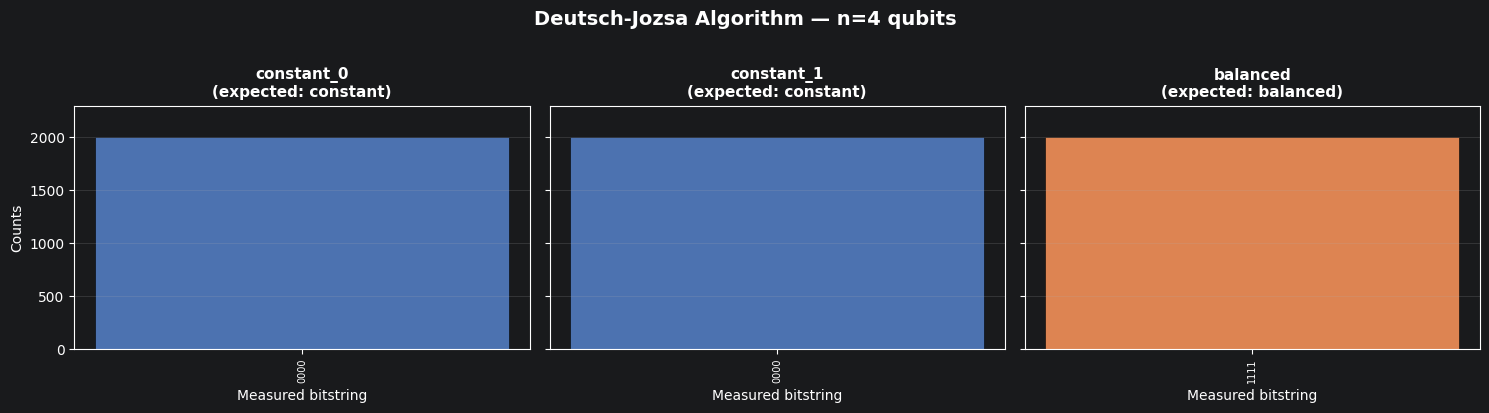

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (oracle_type, expected_class) in zip(axes, dj_oracles.items()):
    counts = dj_results[oracle_type]["counts"]

    # Sort by bitstring
    labels = sorted(counts.keys())
    values = [counts[l] for l in labels]

    all_zeros_key = "0" * n_qubits
    colors = ["#4C72B0" if l == all_zeros_key else "#DD8452" for l in labels]

    bars = ax.bar(range(len(labels)), values, color=colors, edgecolor="black", linewidth=0.4)
    ax.set_title(f"{oracle_type}\n(expected: {expected_class})",
                 fontsize=11, fontweight="bold", fontfamily="DejaVu Sans")
    ax.set_xlabel("Measured bitstring")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_ylim(0, shots * 1.15)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Counts")
fig.suptitle(f"Deutsch-Jozsa Algorithm — n={n_qubits} qubits",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Validation — Deutsch–Jozsa

In [13]:
for oracle_type, expected_class in dj_oracles.items():
    verdict = dj_results[oracle_type]["verdict"]
    assert verdict == expected_class, (
        f"{oracle_type}: expected {expected_class}, got {verdict}"
    )

# Constant oracles must yield all-zeros with certainty
for c_type in ["constant_0", "constant_1"]:
    c = dj_results[c_type]["counts"]
    all_zeros_key = "0" * n_qubits
    assert c.get(all_zeros_key, 0) == shots, (
        f"{c_type}: expected {shots} counts of {all_zeros_key}, got {c.get(all_zeros_key, 0)}"
    )

# Balanced oracle must never yield all-zeros
all_zeros_key = "0" * n_qubits
assert dj_results["balanced"]["counts"].get(all_zeros_key, 0) == 0, (
    f"balanced: should have 0 counts of {all_zeros_key}"
)

print("✅  Deutsch-Jozsa: all oracles correctly classified with a single query.")

✅  Deutsch-Jozsa: all oracles correctly classified with a single query.


---

## Part 3 — Scaling: classical vs. quantum queries

Let's visualize the exponential gap between classical and quantum query complexity.

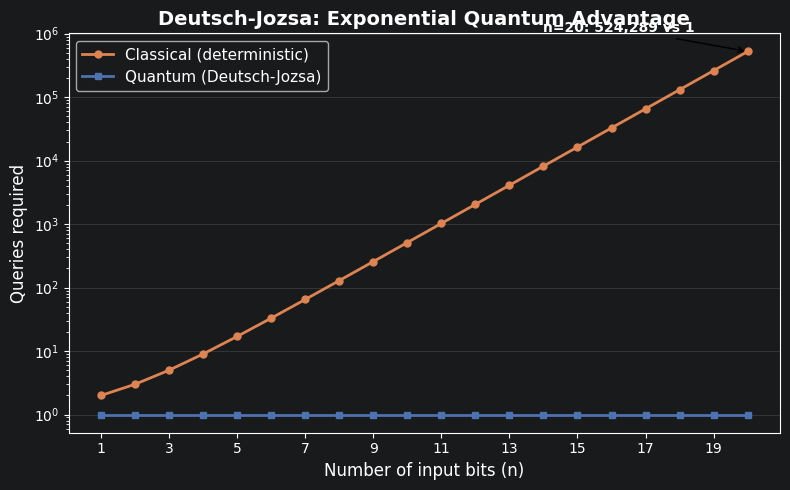

In [14]:
n_vals = np.arange(1, 21)
classical_queries = 2**(n_vals - 1) + 1
quantum_queries = np.ones_like(n_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(n_vals, classical_queries, 'o-', color="#DD8452", linewidth=2,
            markersize=5, label="Classical (deterministic)")
ax.semilogy(n_vals, quantum_queries, 's-', color="#4C72B0", linewidth=2,
            markersize=5, label="Quantum (Deutsch-Jozsa)")

ax.set_xlabel("Number of input bits (n)", fontsize=12)
ax.set_ylabel("Queries required", fontsize=12)
ax.set_title("Deutsch-Jozsa: Exponential Quantum Advantage",
             fontsize=14, fontweight="bold", fontfamily="DejaVu Sans")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.25)
ax.set_xticks(n_vals[::2])

# Annotate the gap
ax.annotate(f"n=20: {int(classical_queries[-1]):,} vs 1",
            xy=(20, classical_queries[-1]), xytext=(14, classical_queries[-1] * 2),
            fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black"))

plt.tight_layout()
plt.show()

---

## Part 4 — The universal blueprint

Both Deutsch and Deutsch–Jozsa follow the **same pattern**. This pattern is the blueprint for
virtually every quantum algorithm:

$$\boxed{\text{Prepare} \;\to\; \text{Oracle} \;\to\; \text{Interfere} \;\to\; \text{Measure}}$$

| Step | What happens | Which notebook |
|:-----|:-------------|:--------------:|
| **Prepare** | $H^{\otimes n}$ creates uniform superposition | 100 |
| **Oracle** | $U_f$ encodes problem information into phases | 102 (unitarity) |
| **Interfere** | $H^{\otimes n}$ (or QFT, or Grover diffusion) converts phases → amplitudes | 101 ($H^2 = I$) |
| **Measure** | Collapse extracts the answer | 101 |

### How this extends to other algorithms

The Deutsch and Deutsch–Jozsa algorithms are the simplest members of a **family** that uses this exact blueprint:

| Algorithm | Input size | Oracle encodes | Interference step | Speedup |
|:----------|:----------:|:---------------|:-------------------|:--------|
| **Deutsch** | 1 bit | constant vs balanced | $H$ | 2× |
| **Deutsch–Jozsa** | $n$ bits | constant vs balanced | $H^{\otimes n}$ | Exponential |
| **Bernstein–Vazirani** | $n$ bits | hidden string $s$ | $H^{\otimes n}$ | Exponential |
| **Simon** | $n$ bits | hidden period $s$ | $H^{\otimes n}$ | Exponential |
| **Grover** | $n$ bits | marked item | $2|\psi\rangle\langle\psi| - I$ | Quadratic ($\sqrt{N}$) |
| **QPE** | phase bits | eigenvalue phase | $\text{QFT}^\dagger$ | Exponential |
| **Shor** | $n$ bits | period of modular exp | $\text{QFT}^\dagger$ | Exponential |

In every case:
1. **Superposition** lets the oracle process all inputs at once
2. **Phase encoding** stores the answer invisibly (unmeasurable)
3. **Interference** converts invisible phases into measurable amplitudes
4. **Measurement** collapses to the answer

The key evolutionary step from algorithm to algorithm is **how the interference transform changes** —
from simple $H^{\otimes n}$ (Deutsch–Jozsa, Bernstein–Vazirani) to amplitude amplification (Grover)
to the Quantum Fourier Transform (QPE, Shor).

**Notebook 104** explores these extensions in detail (see 'Boris intuition').

---

## Takeaways

| Concept | Key point |
|:--------|:----------|
| **Deutsch algorithm** | First quantum speedup ever: determines constant vs balanced with **1 query** instead of 2 |
| **Phase kickback** | Oracle output is encoded into the **phase** of the input qubit via the $|{-}\rangle$ ancilla |
| **Interference** | Final Hadamard converts phase differences into amplitude differences → measurable |
| **Deutsch–Jozsa** | Generalizes to $n$ bits: **1 query** vs $2^{n-1}+1$ classical queries |
| **Exponential gap** | The quantum advantage grows exponentially with $n$ |
| **Universal blueprint** | Prepare → Oracle → Interfere → Measure — every major quantum algorithm follows this pattern |
| **Phase → amplitude** | The deep principle: information is encoded in unobservable phases, then interference makes it observable |
| **Connection to 100–102** | Superposition (100) + reversibility (101) + unitarity (102) = quantum algorithms |

**What's next:** Notebook **104** takes this blueprint and applies it to progressively more powerful algorithms —
Bernstein–Vazirani, Grover's search, Quantum Phase Estimation, and Simon's algorithm — showing how the
interference step evolves while the overall structure remains the same.